# Phase 0: Pipeline Validation

## Phase 0A: PulseLM Dataset Audit
- [x] Load all 16 PulseLM datasets
- [x] Save locally as parquet
- [ ] Schema inspection
- [ ] Dataset-level descriptive statistics
- [ ] Signal/text/QA structure review
- [ ] Confirm benchmark/foundation-model readiness

## Phase 0B: Raw Signal Preprocessing (WESAD)
- [ ] Load WESAD wrist BVP/PPG (64 Hz)
- [ ] Resample to 125 Hz
- [ ] Apply fourth-order Butterworth low-pass filter at 8 Hz
- [ ] Remove DC offset
- [ ] Slice into 10-second windows
- [ ] Per-segment min-max normalization

In [1]:
import os
import sys
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = os.getcwd()
sys.path.append(os.path.join(notebook_dir, '../signal/'))

from data_processing import DataProcessing

Top-level keys    : ['signal', 'label', 'subject']
Signal keys       : ['chest', 'wrist']
Wrist signal keys : ['ACC', 'BVP', 'EDA', 'TEMP']
Label shape       : (4255300,)

Raw BVP shape   : (389056,)
Label shape     : (4255300,)
Unique labels   : [0 1 2 3 4 6 7]

Downsampled label shape : (389056,)
BVP shape               : (389056,)

BVP after label filter  : (184896,)
Unique labels remaining : [1 2 3 4]

Full pipeline output shape : (288, 1250)


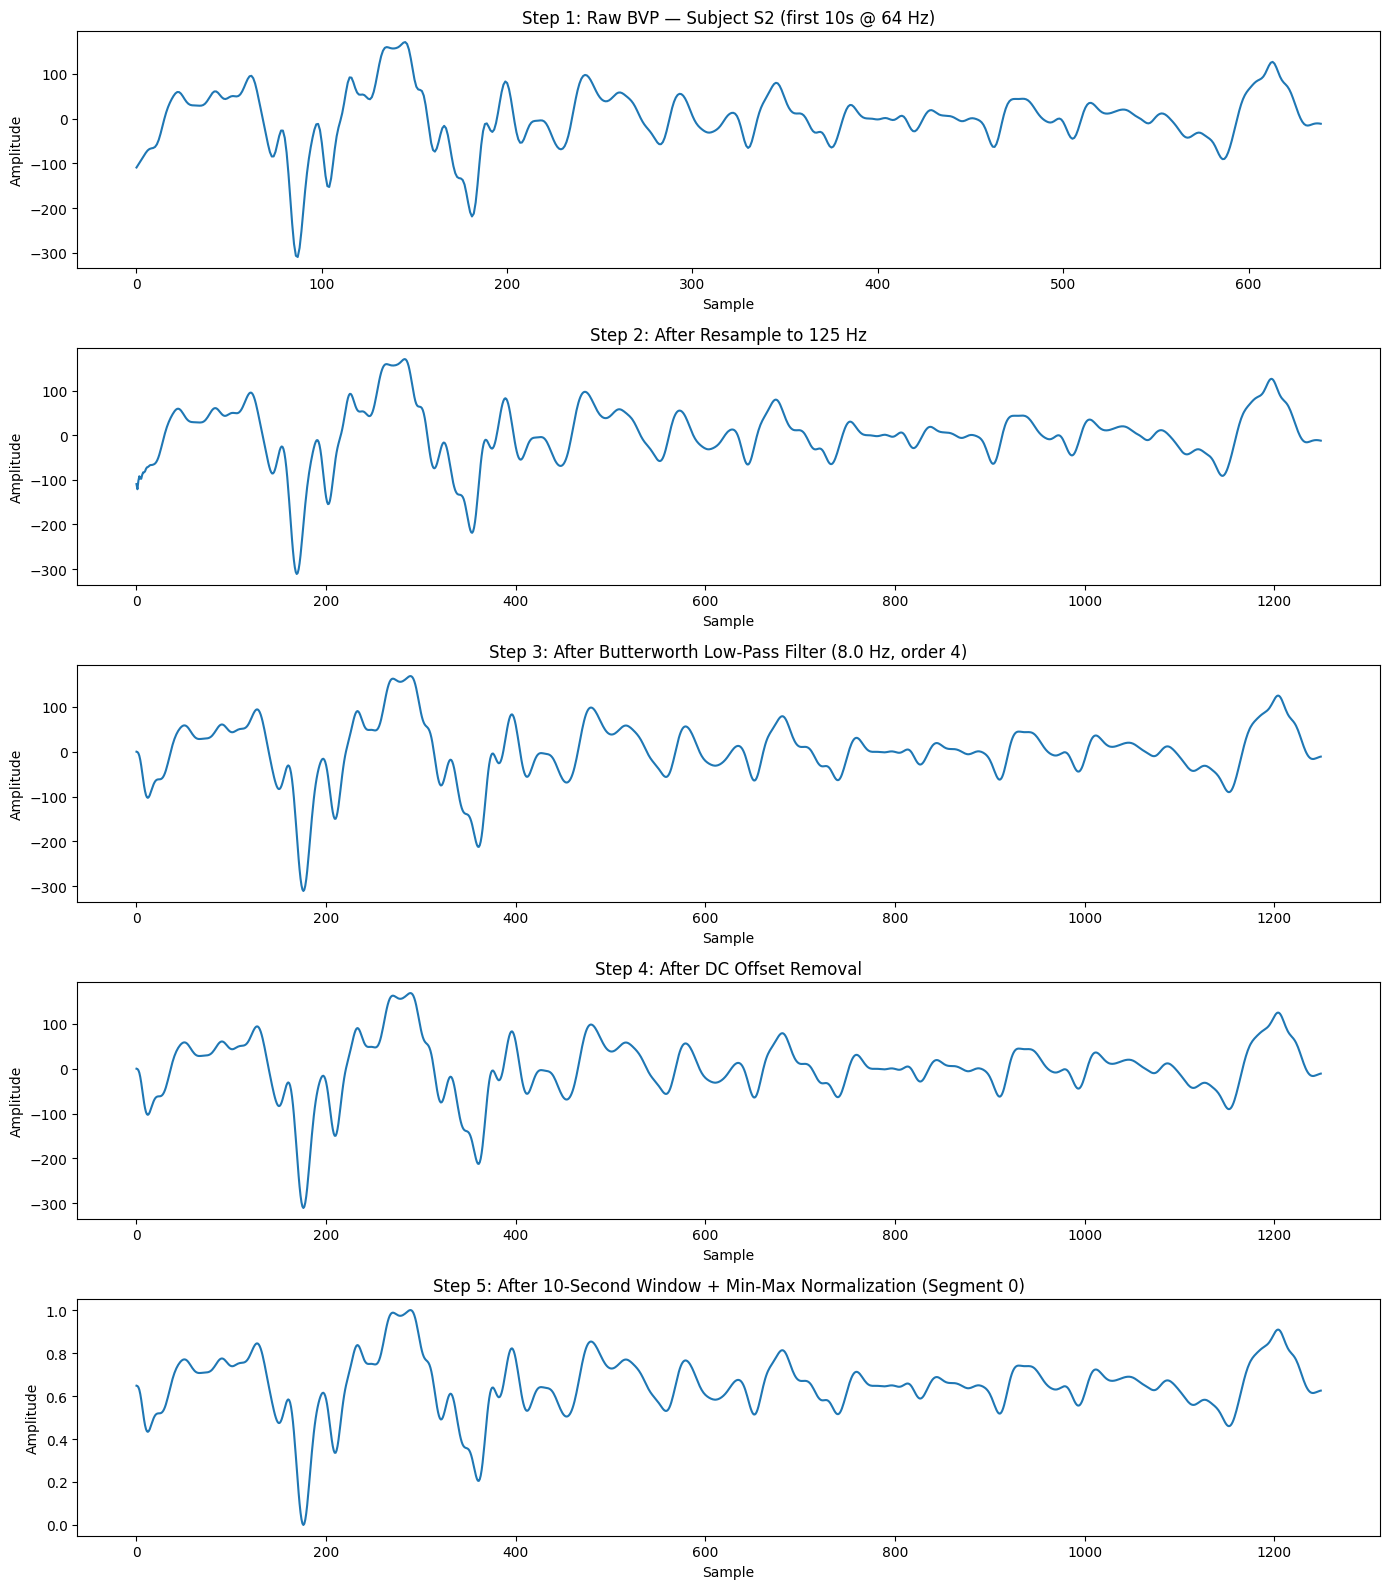

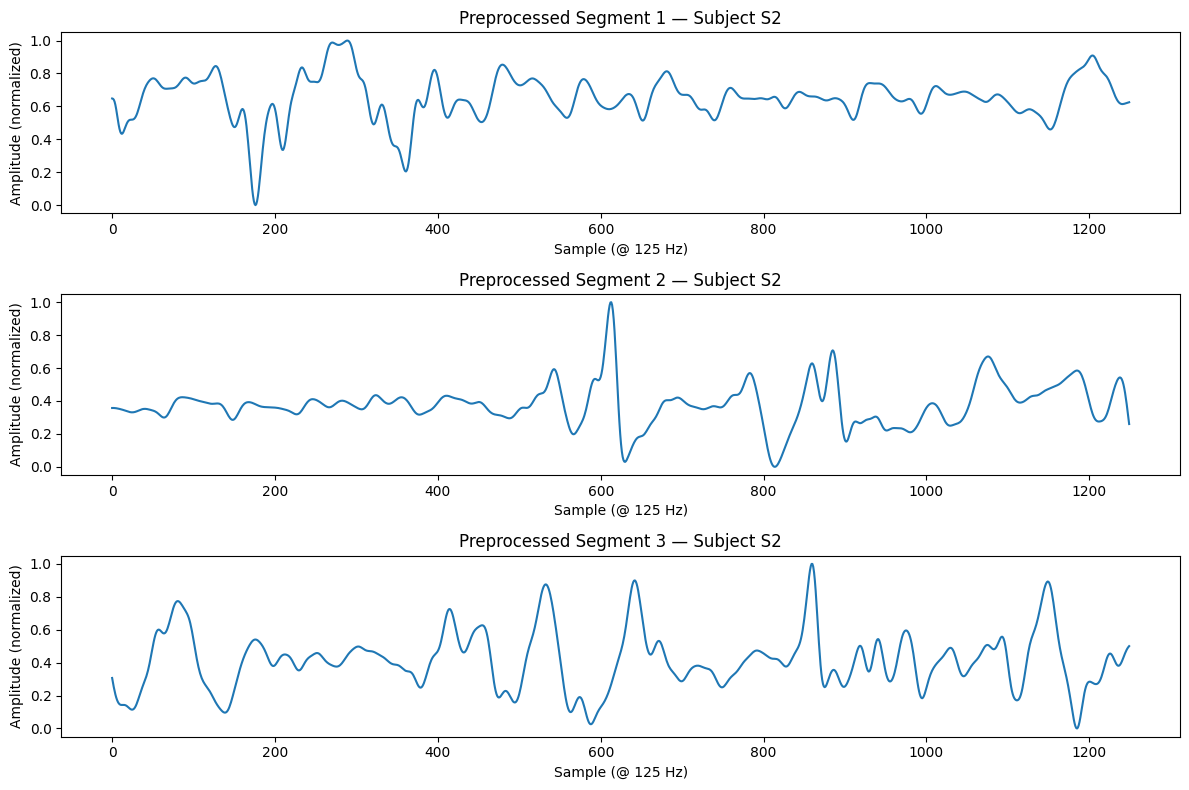


Running Phase 0B pipeline on all WESAD subjects...
  S2 :  184,896 raw samples →  288 segments of shape (288, 1250)
  S3 :  187,840 raw samples →  293 segments of shape (293, 1250)
  S4 :  190,080 raw samples →  297 segments of shape (297, 1250)
  S5 :  192,705 raw samples →  301 segments of shape (301, 1250)
  S6 :  191,297 raw samples →  298 segments of shape (298, 1250)
  S7 :  191,234 raw samples →  298 segments of shape (298, 1250)
  S8 :  192,320 raw samples →  300 segments of shape (300, 1250)
  S9 :  191,360 raw samples →  299 segments of shape (299, 1250)
  S10 :  196,672 raw samples →  307 segments of shape (307, 1250)
  S11 :  193,216 raw samples →  301 segments of shape (301, 1250)
  S13 :  193,344 raw samples →  302 segments of shape (302, 1250)
  S14 :  193,344 raw samples →  302 segments of shape (302, 1250)
  S15 :  193,727 raw samples →  302 segments of shape (302, 1250)
  S16 :  192,832 raw samples →  301 segments of shape (301, 1250)
  S17 :  192,448 raw samples →  

In [2]:
FS_ORIGINAL  = 64
FS_TARGET    = 125
CUTOFF_HZ    = 8.0
FILTER_ORDER = 4
WINDOW_SEC   = 10

# Path to WESAD subject folders
WESAD_PATH = os.path.join(notebook_dir, "../../data/WESAD/per_subject")

# S1 and S12 excluded due to sensor malfunction [7]
SUBJECT_IDS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 
                'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

# Load a single subject from pkl (synchronized data + labels) [7]
def load_subject_pkl(wesad_path: str, subject_id: str) -> dict:
    pkl_path = os.path.join(wesad_path, subject_id, f"{subject_id}.pkl")
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

# Inspect structure of one subject first
subject_id = 'S2'
data = load_subject_pkl(WESAD_PATH, subject_id)

print("Top-level keys    :", list(data.keys()))
print("Signal keys       :", list(data['signal'].keys()))
print("Wrist signal keys :", list(data['signal']['wrist'].keys()))
print("Label shape       :", data['label'].shape)

# Extract synchronized wrist BVP and labels [7]
bvp   = data['signal']['wrist']['BVP'].flatten()
label = data['label'].flatten()

print(f"\nRaw BVP shape   : {bvp.shape}")
print(f"Label shape     : {label.shape}")
print(f"Unique labels   : {np.unique(label)}")

# Labels are synced to chest (700 Hz), BVP is at 64 Hz [7]
# Downsample labels to match BVP length per subject
label_downsampled = np.interp(
    np.linspace(0, len(label), len(bvp)),
    np.arange(len(label)),
    label
).astype(int)

print(f"\nDownsampled label shape : {label_downsampled.shape}")
print(f"BVP shape               : {bvp.shape}")

# Filter meaningful labels (1=baseline, 2=stress, 3=amusement, 4=meditation)
valid_labels = np.isin(label_downsampled, [1, 2, 3, 4])
bvp_filtered = bvp[valid_labels]
labels_filtered = label_downsampled[valid_labels]

print(f"\nBVP after label filter  : {bvp_filtered.shape}")
print(f"Unique labels remaining : {np.unique(labels_filtered)}")

# Run full preprocessing pipeline on filtered BVP [8]
normalized_pipeline = DataProcessing.preprocess_ppg_pipeline(
    signal      = bvp_filtered,
    fs_original = FS_ORIGINAL,
    fs_target   = FS_TARGET,
    cutoff      = CUTOFF_HZ,
    order       = FILTER_ORDER,
    window_sec  = WINDOW_SEC
)
print(f"\nFull pipeline output shape : {normalized_pipeline.shape}")

# Visualize each step on first 10 seconds
resampled  = DataProcessing.resample_signal(bvp_filtered, FS_ORIGINAL, FS_TARGET)
filtered   = DataProcessing.butterworth_lowpass(resampled, fs=FS_TARGET, cutoff=CUTOFF_HZ, order=FILTER_ORDER)
dc_removed = DataProcessing.remove_dc_offset(filtered)

os.makedirs(os.path.join(notebook_dir, "../outputs"), exist_ok=True)

fig, axes = plt.subplots(5, 1, figsize=(14, 16))
axes[0].plot(bvp_filtered[:FS_ORIGINAL * WINDOW_SEC])
axes[0].set_title(f"Step 1: Raw BVP — Subject {subject_id} (first {WINDOW_SEC}s @ {FS_ORIGINAL} Hz)")
axes[1].plot(resampled[:FS_TARGET * WINDOW_SEC])
axes[1].set_title(f"Step 2: After Resample to {FS_TARGET} Hz")
axes[2].plot(filtered[:FS_TARGET * WINDOW_SEC])
axes[2].set_title(f"Step 3: After Butterworth Low-Pass Filter ({CUTOFF_HZ} Hz, order {FILTER_ORDER})")
axes[3].plot(dc_removed[:FS_TARGET * WINDOW_SEC])
axes[3].set_title("Step 4: After DC Offset Removal")
axes[4].plot(normalized_pipeline[0])
axes[4].set_title("Step 5: After 10-Second Window + Min-Max Normalization (Segment 0)")
for ax in axes:
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.savefig(os.path.join(notebook_dir, "../outputs/phase0b_pipeline_steps.png"), dpi=150)
plt.show()

# Visualize 3 normalized segments
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, ax in enumerate(axes):
    ax.plot(normalized_pipeline[i])
    ax.set_title(f"Preprocessed Segment {i+1} — Subject {subject_id}")
    ax.set_xlabel(f"Sample (@ {FS_TARGET} Hz)")
    ax.set_ylabel("Amplitude (normalized)")
plt.tight_layout()
plt.savefig(os.path.join(notebook_dir, "../outputs/phase0b_normalized_segments.png"), dpi=150)
plt.show()

# Generalize to all subjects
SUBJECT_IDS = [f'S{i}' for i in range(2, 18) if i not in [1, 12]]  # S1 and S12 excluded [7]

print(f"\n{'='*60}")
print("Running Phase 0B pipeline on all WESAD subjects...")
print(f"{'='*60}")

all_subjects_segments = {}
for sid in SUBJECT_IDS:
    try:
        d          = load_subject_pkl(WESAD_PATH, sid)
        bvp_s      = d['signal']['wrist']['BVP'].flatten()
        label_s    = d['label'].flatten()

        label_ds   = np.interp(
            np.linspace(0, len(label_s), len(bvp_s)),
            np.arange(len(label_s)),
            label_s
        ).astype(int)

        valid      = np.isin(label_ds, [1, 2, 3, 4])
        bvp_s      = bvp_s[valid]

        segments   = DataProcessing.preprocess_ppg_pipeline(
            signal      = bvp_s,
            fs_original = FS_ORIGINAL,
            fs_target   = FS_TARGET,
            cutoff      = CUTOFF_HZ,
            order       = FILTER_ORDER,
            window_sec  = WINDOW_SEC
        )
        all_subjects_segments[sid] = segments
        print(f"  {sid} : {len(bvp_s):>8,} raw samples → {segments.shape[0]:>4} segments of shape {segments.shape}")
    except Exception as e:
        print(f"  {sid} : ERROR — {e}")

print(f"\nTotal subjects processed : {len(all_subjects_segments)}")
total_segments = sum(v.shape[0] for v in all_subjects_segments.values())
print(f"Total segments produced  : {total_segments:,}")
print(f"Segment shape            : ({FS_TARGET * WINDOW_SEC},) = ({FS_TARGET} Hz × {WINDOW_SEC}s)")
print("\nPhase 0B complete. Segments are ready for PaPaGei embedding extraction.")